Time Series forecasting model

In [ ]:
!python --version


Python 3.12.12


In [80]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !pip uninstall -y prophet fbprophet pystan
# !pip install prophet==1.1.5 pystan==2.19.1.1
!pip install prophet-cmdstan


ERROR: Could not find a version that satisfies the requirement prophet-cmdstan (from versions: none)
ERROR: No matching distribution found for prophet-cmdstan


In [ ]:
!pip show prophet


Name: prophet
Version: 1.1.7
Summary: Automatic Forecasting Procedure
Home-page: https://facebook.github.io/prophet/
Author: 
Author-email: "Sean J. Taylor" <sjtz@pm.me>, Ben Letham <bletham@fb.com>
License: MIT
Location: /usr/local/lib/python3.11/dist-packages
Requires: cmdstanpy, holidays, importlib_resources, matplotlib, numpy, pandas, tqdm
Required-by: 


In [ ]:
import pandas as pd
import os

# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/AgriYield_cleaned.csv")

In [ ]:
set(df['Soil_Type'])

{'Clay', 'Loamy', 'Peaty', 'Saline', 'Sandy'}

In [ ]:
# STEP 1: Prepare monthly time-series data for each crop

import pandas as pd
import os

# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/AgriYield_cleaned.csv")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Convert Yield column to numeric & remove invalid rows
df["Crop_Yield"] = pd.to_numeric(df["Crop_Yield"], errors="coerce")
df = df.dropna(subset=["Date", "Crop_Type", "Crop_Yield"])

# Create output folder to store each crop monthly data
output_folder = "monthly_series_by_crop"
os.makedirs(output_folder, exist_ok=True)

monthly_series_dict = {}   # To store in memory
summary_list = []          # For summary table

# Process each crop separately
for crop, group in df.groupby("Crop_Type"):
    # Resample to monthly average
    monthly = (
        group.set_index("Date")["Crop_Yield"]
        .resample("M")
        .mean()
        .reset_index()
        .rename(columns={"Date": "ds", "Crop_Yield": "y"})
    )

    # Drop missing values
    monthly = monthly.dropna(subset=["y"]).reset_index(drop=True)

    # Store in dictionary (for model training later)
    monthly_series_dict[crop] = monthly

    # Save to CSV
    file_name = crop.replace(" ", "_").replace("/", "_") + "_monthly.csv"
    monthly.to_csv(os.path.join(output_folder, file_name), index=False)

    # Add to summary
    summary_list.append([
        crop,
        len(monthly),
        monthly["ds"].min(),
        monthly["ds"].max()
    ])

# Create summary table
summary_df = pd.DataFrame(summary_list, columns=[
    "Crop Name", "Monthly Records", "Start Date", "End Date"
])

print("✅ Step 1 Completed Successfully")
print(f"📁 Monthly files saved in: {output_folder}")
print("\n📊 Dataset Summary:\n")
print(summary_df)


In [ ]:
# STEP 2: Seasonality and Stationarity Analysis

import pandas as pd
import glob
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

folder = "monthly_series_by_crop"
files = glob.glob(folder + "/*.csv")

def adf_test(series):
    result = adfuller(series, autolag='AIC')
    return result[1]  # p-valuea

def kpss_test(series):
    result = kpss(series, regression='c')
    return result[1]  # p-value

analysis_results = []

for file in files:
    df = pd.read_csv(file)
    crop_name = file.split("/")[-1].replace("_monthly.csv", "").replace("_", " ")

    y = df["y"]

    # ADF & KPSS Tests
    adf_p = adf_test(y)
    kpss_p = kpss_test(y)

    # Determine stationarity interpretation
    if adf_p < 0.05 and kpss_p > 0.05:
        stationarity = "✅ Stationary"
    else:
        stationarity = "⚠️ Not Stationary (Needs Differencing)"

    # Seasonality Strength
    decomposition = seasonal_decompose(y, period=12, model='additive')
    seasonal_strength = decomposition.seasonal.var() / (decomposition.seasonal.var() + decomposition.resid.var())

    analysis_results.append([crop_name, adf_p, kpss_p, seasonality := round(seasonal_strength, 3), stationarity])

# Create output summary table
analysis_df = pd.DataFrame(analysis_results, columns=[
    "Crop Name", "ADF p-value", "KPSS p-value", "Seasonality Strength (0-1)", "Stationarity Result"
])

print("✅ Step 2 Completed\n")
print(analysis_df)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/tqh6ssjp.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/zuqez56j.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=86177', 'data', 'file=/tmp/tmpv91xnojp/tqh6ssjp.json', 'init=/tmp/tmpv91xnojp/zuqez56j.json', 'output', 'file=/tmp/tmpv91xnojp/prophet_model76q3bho3/prophet_model-20251111081904.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
08:19:04 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:19:04 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages

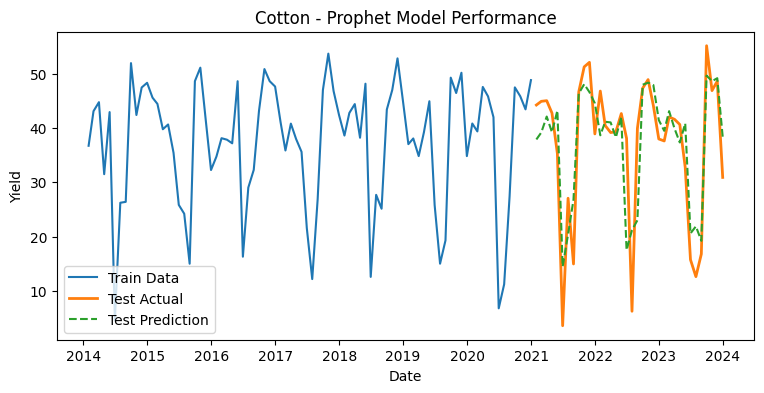

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/gdbqryw4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/wio9lg82.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=67755', 'data', 'file=/tmp/tmpv91xnojp/gdbqryw4.json', 'init=/tmp/tmpv91xnojp/wio9lg82.json', 'output', 'file=/tmp/tmpv91xnojp/prophet_model24l8r3s_/prophet_model-20251111081904.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
08:19:04 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:19:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages

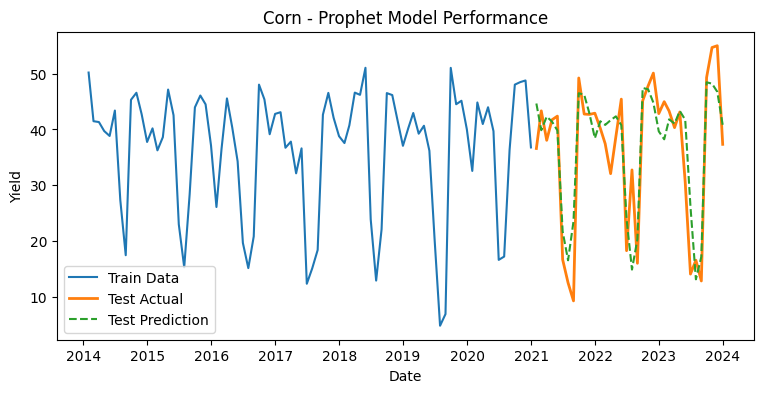

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/yw5na2v7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/dawyn1yi.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=43865', 'data', 'file=/tmp/tmpv91xnojp/yw5na2v7.json', 'init=/tmp/tmpv91xnojp/dawyn1yi.json', 'output', 'file=/tmp/tmpv91xnojp/prophet_modelef37vupa/prophet_model-20251111081905.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
08:19:05 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:19:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages

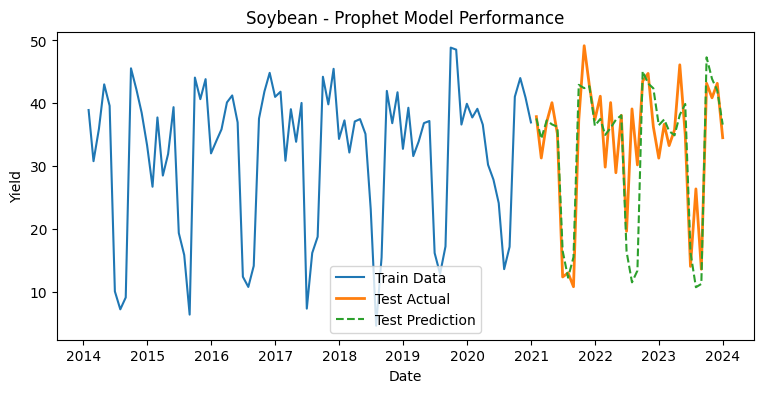

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/cmiha7pt.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/qtaus_4j.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=47212', 'data', 'file=/tmp/tmpv91xnojp/cmiha7pt.json', 'init=/tmp/tmpv91xnojp/qtaus_4j.json', 'output', 'file=/tmp/tmpv91xnojp/prophet_modelwvvcx178/prophet_model-20251111081906.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
08:19:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:19:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages

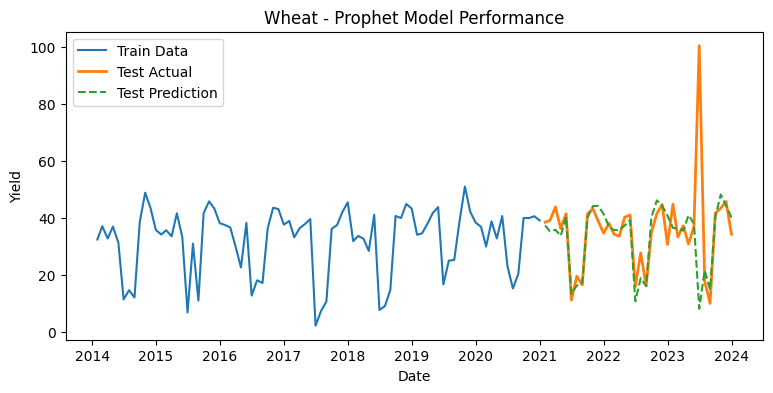

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/w48vdm7_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/whlzxyoe.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=94187', 'data', 'file=/tmp/tmpv91xnojp/w48vdm7_.json', 'init=/tmp/tmpv91xnojp/whlzxyoe.json', 'output', 'file=/tmp/tmpv91xnojp/prophet_modelf81sna4l/prophet_model-20251111081907.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
08:19:07 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:19:07 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages

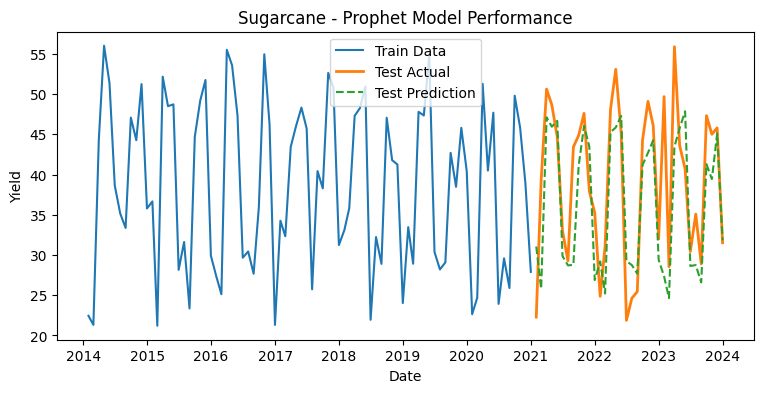

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/muw2qlfg.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/08ihd7q1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=83099', 'data', 'file=/tmp/tmpv91xnojp/muw2qlfg.json', 'init=/tmp/tmpv91xnojp/08ihd7q1.json', 'output', 'file=/tmp/tmpv91xnojp/prophet_modelvrtz39gq/prophet_model-20251111081907.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
08:19:07 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:19:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages

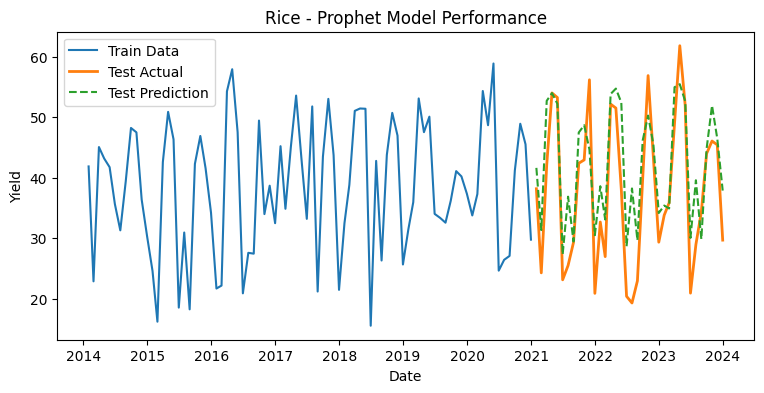

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/20i8utyi.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/zzt658gx.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=58024', 'data', 'file=/tmp/tmpv91xnojp/20i8utyi.json', 'init=/tmp/tmpv91xnojp/zzt658gx.json', 'output', 'file=/tmp/tmpv91xnojp/prophet_modeldl3xb9fq/prophet_model-20251111081908.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
08:19:08 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:19:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages

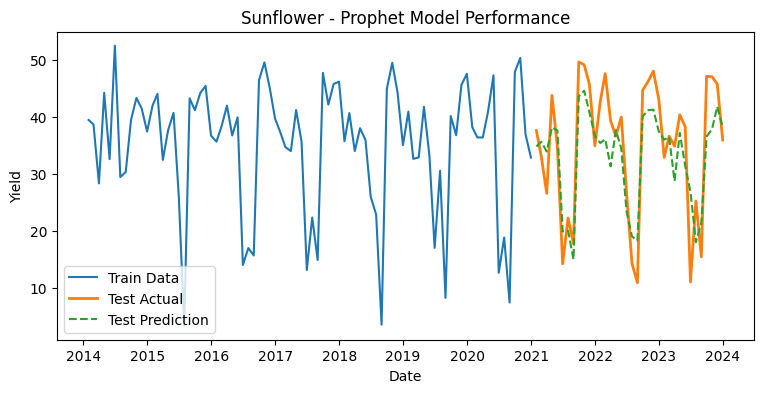

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/dlrzr2dy.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/daeor8gf.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=37465', 'data', 'file=/tmp/tmpv91xnojp/dlrzr2dy.json', 'init=/tmp/tmpv91xnojp/daeor8gf.json', 'output', 'file=/tmp/tmpv91xnojp/prophet_modelr6w3ito7/prophet_model-20251111081909.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
08:19:09 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:19:09 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages

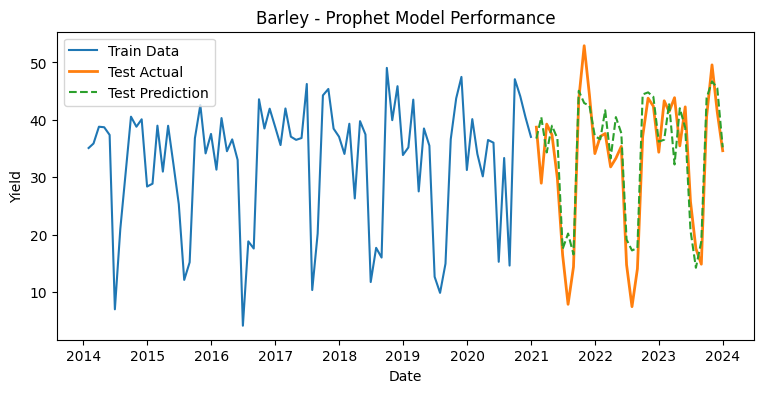

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/9ouni536.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/ibq198z1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=90239', 'data', 'file=/tmp/tmpv91xnojp/9ouni536.json', 'init=/tmp/tmpv91xnojp/ibq198z1.json', 'output', 'file=/tmp/tmpv91xnojp/prophet_modelagyhaoqd/prophet_model-20251111081909.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
08:19:09 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:19:10 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages

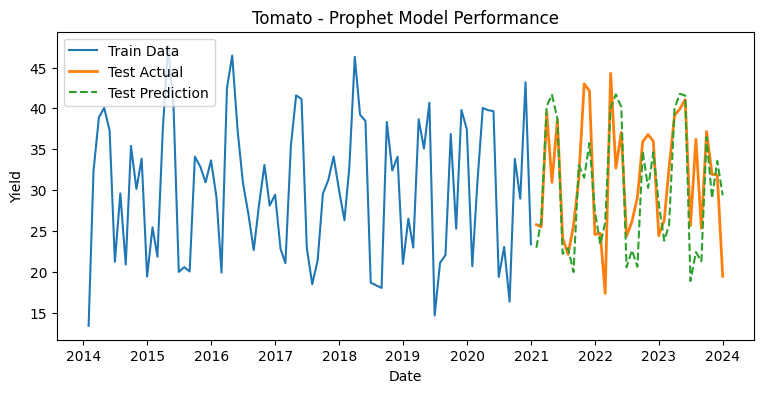

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/hhmaa4oq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpv91xnojp/1_69od78.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=64767', 'data', 'file=/tmp/tmpv91xnojp/hhmaa4oq.json', 'init=/tmp/tmpv91xnojp/1_69od78.json', 'output', 'file=/tmp/tmpv91xnojp/prophet_modellgm6je89/prophet_model-20251111081910.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
08:19:10 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:19:10 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages

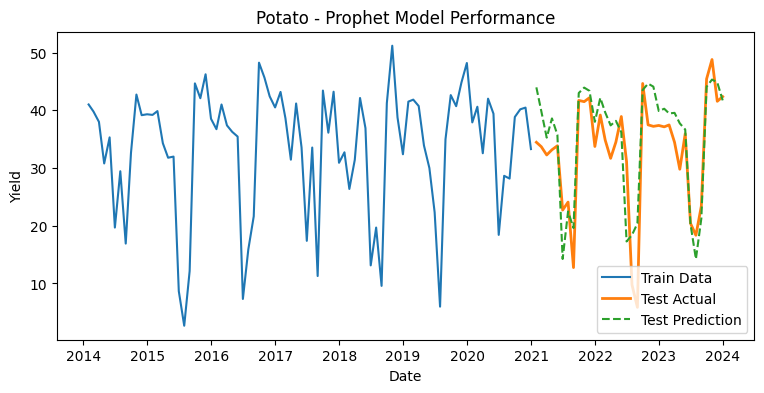


✅ STEP 3 Completed — Model Performance Summary:

   Crop Name       MAE         MSE       RMSE  MAPE (%)     R²
7     Barley  4.370651   29.937103   5.471481       NaN  0.786
1       Corn  4.833412   39.317481   6.270365       NaN  0.762
6  Sunflower  5.416320   38.839950   6.232171       NaN  0.716
0     Cotton  5.323779   51.512310   7.177208       NaN  0.690
9     Potato  4.465233   31.623962   5.623519       NaN  0.672
5       Rice  5.860154   52.430146   7.240866       NaN  0.639
2    Soybean  4.502601   49.359465   7.025629       NaN  0.521
4  Sugarcane  5.249574   47.776137   6.912028       NaN  0.469
8     Tomato  4.270090   30.957086   5.563909       NaN  0.388
3      Wheat  6.099492  257.841254  16.057436       NaN -0.162


In [ ]:
# STEP 3: Train/Test Prophet & Evaluate Models

import pandas as pd
import glob
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

folder = "monthly_series_by_crop"
files = glob.glob(folder + "/*.csv")

results = []

FORECAST_HORIZON = 36  # Test size = last 36 months

for file in files:
    df = pd.read_csv(file)
    crop_name = file.split("/")[-1].replace("_monthly.csv", "").replace("_", " ")

    # Ensure proper datetime format
    df["ds"] = pd.to_datetime(df["ds"])

    if len(df) <= FORECAST_HORIZON + 12:
        print(f"⏭️ Skipping {crop_name}: Not enough data for train/test split")
        continue

    # Train-Test Split
    train = df.iloc[:-FORECAST_HORIZON]
    test = df.iloc[-FORECAST_HORIZON:]

    # Prophet Model
    model = Prophet(yearly_seasonality=True, seasonality_mode="multiplicative")
    model.fit(train)

    # Predict on Test
    future = model.make_future_dataframe(periods=FORECAST_HORIZON, freq="M")
    forecast = model.predict(future)

    # Extract predictions matching test period
    pred = forecast.set_index("ds").loc[test["ds"], "yhat"]

    # Metrics
    mae = mean_absolute_error(test["y"], pred)
    mse = mean_squared_error(test["y"], pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((test["y"] - pred) / test["y"])) * 100
    r2 = r2_score(test["y"], pred)

    # Save to results
    results.append([crop_name, mae, mse, rmse, round(mape, 2), round(r2, 3)])

    # ---- Plot Train vs Test vs Prediction ----
    plt.figure(figsize=(9,4))
    plt.plot(train["ds"], train["y"], label="Train Data")
    plt.plot(test["ds"], test["y"], label="Test Actual", linewidth=2)
    plt.plot(test["ds"], pred, label="Test Prediction", linestyle="--")
    plt.title(f"{crop_name} - Prophet Model Performance")
    plt.xlabel("Date")
    plt.ylabel("Yield")
    plt.legend()
    plt.show()

# Convert results to a table
performance_df = pd.DataFrame(results, columns=[
    "Crop Name", "MAE", "MSE", "RMSE", "MAPE (%)", "R²"
])

print("\n✅ STEP 3 Completed — Model Performance Summary:\n")
print(performance_df.sort_values("R²", ascending=False))


Time Series with Regressor

In [93]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [94]:
import os
import pandas as pd
import numpy as np

In [95]:
INPUT_CSV = "/content/drive/MyDrive/AgriYield_cleaned.csv"   # update if needed
OUTPUT_FOLDER = "monthly_series_by_crop_with_regressors"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

In [96]:
df = pd.read_csv(INPUT_CSV)

In [97]:
numeric_cols = ['Soil_pH', 'Temperature', 'Humidity', 'Wind_Speed', 'N', 'P', 'K', 'Soil_Quality']
for col in numeric_cols:
    corr = df[col].corr(df['Crop_Yield'])
    print(f"{col}: correlation with yield = {corr:.3f}")


Soil_pH: correlation with yield = -0.022
Temperature: correlation with yield = -0.042
Humidity: correlation with yield = 0.295
Wind_Speed: correlation with yield = -0.004
N: correlation with yield = 0.236
P: correlation with yield = 0.275
K: correlation with yield = 0.256
Soil_Quality: correlation with yield = 0.326


In [98]:
# STEP 1 (with regressors): prepare monthly time-series for each crop
# - Reads the original CSV
# - Converts Date -> ds, Crop_Yield -> y
# - Finds all numeric columns (keeps Crop_Yield as y and other numeric cols as regressors)
# - Resamples monthly (mean) for each numeric regressor and y
# - Saves per-crop CSV files containing: ds, y, <regressor1>, <regressor2>, ...



# STEP 1 (with regressors): prepare monthly time-series for each crop

# --- Load data ---
df = pd.read_csv(INPUT_CSV)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Crop_Yield"] = pd.to_numeric(df["Crop_Yield"], errors="coerce")

df = df.dropna(subset=["Date", "Crop_Type", "Crop_Yield"]).copy()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
regressor_cols = [c for c in numeric_cols if c != "Crop_Yield"]

print(f"Detected numeric regressors: {regressor_cols}")

monthly_series_dict = {}
summary_list = []

for crop, group in df.groupby("Crop_Type"):

    monthly = (
        group.set_index("Date")[ ["Crop_Yield"] + regressor_cols ]
        .resample("ME")
        .mean()
        .reset_index()
        .rename(columns={"Date": "ds", "Crop_Yield": "y"})
    )

    monthly = monthly.dropna(subset=["y"]).reset_index(drop=True)

    monthly_series_dict[crop] = monthly

    # 🔥🔥 FIXED HERE — clean filename
    safe_crop_name = crop.strip().replace(" ", "_").replace("/", "_")
    file_name = f"{safe_crop_name}_monthly_with_regressors.csv"

    monthly.to_csv(os.path.join(OUTPUT_FOLDER, file_name), index=False)

    summary_list.append([
        crop,
        len(monthly),
        monthly["ds"].min() if not monthly.empty else pd.NaT,
        monthly["ds"].max() if not monthly.empty else pd.NaT,
        len([col for col in regressor_cols if col in monthly.columns])
    ])

summary_df = pd.DataFrame(summary_list, columns=[
    "Crop Name", "Monthly Records", "Start Date", "End Date", "Num Numeric Regressors"
])

print("✅ Step 1 with regressors completed.")



Detected numeric regressors: ['Soil_pH', 'Temperature', 'Humidity', 'Wind_Speed', 'N', 'P', 'K', 'Soil_Quality']
✅ Step 1 with regressors completed.


In [99]:
import pandas as pd
import os

# --- USER INPUT REQUIRED --- (Updated to use pre-generated future regressors)
# The future regressors for Rice have already been generated in STEP 2 (cell alL15TcG-Yfb).
# We will use the file from the 'future_regressors' folder.
SAMPLE_DATA_PATH = "future_regressors/Rice_future_regressors.csv"
CROP_TO_PREDICT = "Rice"
# ---------------------------

# Load the sample data
try:
    sample_df = pd.read_csv(SAMPLE_DATA_PATH)
    sample_df["ds"] = pd.to_datetime(sample_df["ds"])
    print(f"✅ Sample data loaded successfully for {CROP_TO_PREDICT} from {SAMPLE_DATA_PATH}.")
    display(sample_df.head())
except FileNotFoundError:
    print(f"❌ Error: Sample data file not found at {SAMPLE_DATA_PATH}. Please ensure STEP 2 was run correctly.")
except KeyError as e:
    print(f"❌ Error: Missing required column in sample data: {e}. Please ensure 'ds' and regressor columns are present.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Sample data loaded successfully for Rice from future_regressors/Rice_future_regressors.csv.


,ds,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Soil_Quality
0,2024-01-31,6.571361,24.179087,75.079440,9.808528,78.210427,60.194240,44.178054,42.141988
1,2024-02-29,6.571145,24.180688,75.078432,9.803414,78.214700,60.198184,44.181669,42.136908
2,2024-03-31,6.570929,24.182288,75.077424,9.798301,78.218973,60.202129,44.185284,42.131827
3,2024-04-30,6.570712,24.183888,75.076416,9.793188,78.223245,60.206073,44.188900,42.126746
4,2024-05-31,6.570496,24.185488,75.075408,9.788075,78.227518,60.210017,44.192515,42.121665


In [103]:
# STEP 2: Forecast regressors for each crop so Prophet can use them later

import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

INPUT_FOLDER = "monthly_series_by_crop_with_regressors"
OUTPUT_FOLDER = "future_regressors"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Forecast horizon
FUTURE_MONTHS = 12

# Helper: generate future months
def generate_future_dates(last_date, periods=12):
    return pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                         periods=periods, freq="ME")

# ============================
# PROCESS EACH CROP FILE
# ============================
for file in os.listdir(INPUT_FOLDER):
    if not file.endswith("_monthly_with_regressors.csv"):
        continue

    # Extract crop name safely (reverse of Step-1)
    crop_name = file.replace("_monthly_with_regressors.csv", "")

    # Load monthly data
    df = pd.read_csv(os.path.join(INPUT_FOLDER, file))
    df["ds"] = pd.to_datetime(df["ds"])

    # Identify regressors (all numeric columns except y)
    regressor_cols = [c for c in df.columns if c not in ["ds", "y"]]

    if len(regressor_cols) == 0:
        print(f"⚠ No regressors found for {crop_name}. Skipping...")
        continue

    # Split training data: up to 2022
    train_df = df[df["ds"] < "2023-01-01"].copy()
    train_df = train_df.sort_values("ds")

    last_date = df["ds"].max()

    # Prepare output future regressor frame
    future_dates = generate_future_dates(last_date, FUTURE_MONTHS)
    future_df = pd.DataFrame({"ds": future_dates})

    # ============================
    # FORECAST EACH REGRESSOR
    # ============================
    for reg in regressor_cols:

        # Fully fill missing values
        y_train = train_df[reg].ffill().bfill()

        # Convert timeline to numeric index
        X_train = np.arange(len(y_train)).reshape(-1, 1)

        # Train simple linear trend model
        model = LinearRegression()
        model.fit(X_train, y_train)

        # Future numeric timeline
        X_future = np.arange(
            len(y_train), len(y_train) + FUTURE_MONTHS
        ).reshape(-1, 1)

        # Predictions
        future_df[reg] = model.predict(X_future)

    # Save forecasted regressors
    out_file = os.path.join(
        OUTPUT_FOLDER, f"{crop_name}_future_regressors.csv"
    )
    future_df.to_csv(out_file, index=False)

    print(f"✅ Forecasted regressors for {crop_name} → saved: {out_file}")

print("\n🎉 STEP 2 COMPLETED: All future regressor files generated!")


✅ Forecasted regressors for Tomato → saved: future_regressors/Tomato_future_regressors.csv
✅ Forecasted regressors for Rice → saved: future_regressors/Rice_future_regressors.csv
✅ Forecasted regressors for Soybean → saved: future_regressors/Soybean_future_regressors.csv
✅ Forecasted regressors for Sunflower → saved: future_regressors/Sunflower_future_regressors.csv
✅ Forecasted regressors for Barley → saved: future_regressors/Barley_future_regressors.csv
✅ Forecasted regressors for Sugarcane → saved: future_regressors/Sugarcane_future_regressors.csv
✅ Forecasted regressors for Corn → saved: future_regressors/Corn_future_regressors.csv
✅ Forecasted regressors for Cotton → saved: future_regressors/Cotton_future_regressors.csv
✅ Forecasted regressors for Wheat → saved: future_regressors/Wheat_future_regressors.csv
✅ Forecasted regressors for Potato → saved: future_regressors/Potato_future_regressors.csv

🎉 STEP 2 COMPLETED: All future regressor files generated!


In [104]:
!pip install prophet


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



🌾 Training MODEL for Tomato
🔍 Running hyperparameter search...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

✅ Best params → CPS: 0.5, SPS: 1.0, Mode: additive


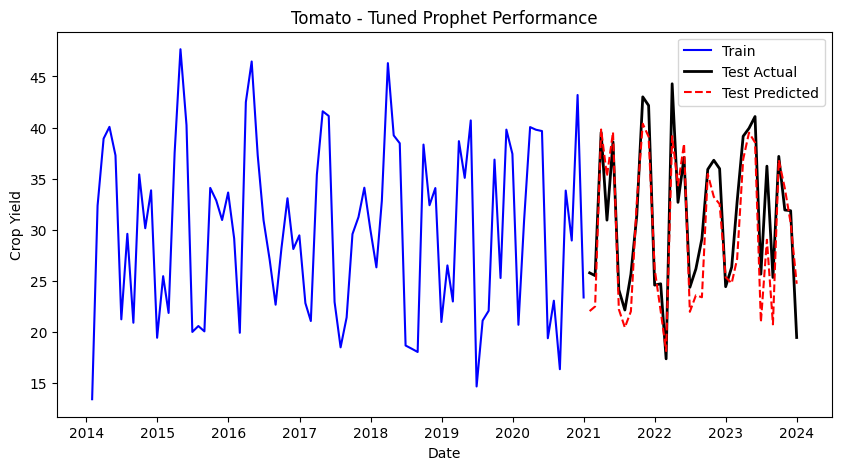

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


📈 Saved future forecast → final_forecasts/Tomato_final_forecast.csv

🌾 Training MODEL for Rice
🔍 Running hyperparameter search...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

✅ Best params → CPS: 0.5, SPS: 10.0, Mode: multiplicative


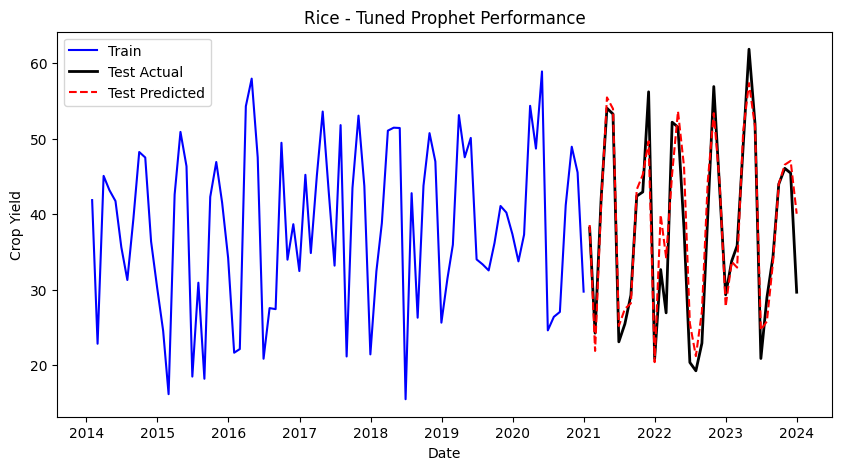

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


📈 Saved future forecast → final_forecasts/Rice_final_forecast.csv

🌾 Training MODEL for Soybean
🔍 Running hyperparameter search...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

✅ Best params → CPS: 0.5, SPS: 5.0, Mode: multiplicative


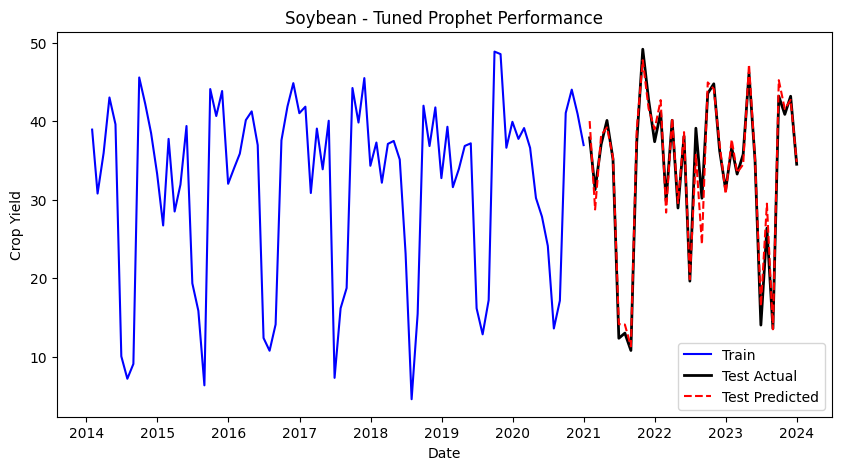

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


📈 Saved future forecast → final_forecasts/Soybean_final_forecast.csv

🌾 Training MODEL for Sunflower
🔍 Running hyperparameter search...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

✅ Best params → CPS: 0.5, SPS: 5.0, Mode: additive


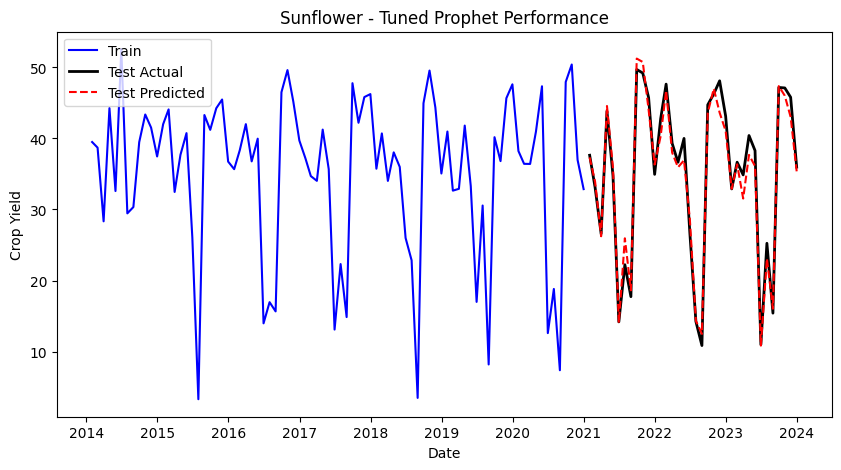

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


📈 Saved future forecast → final_forecasts/Sunflower_final_forecast.csv

🌾 Training MODEL for Barley
🔍 Running hyperparameter search...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

✅ Best params → CPS: 0.5, SPS: 10.0, Mode: additive


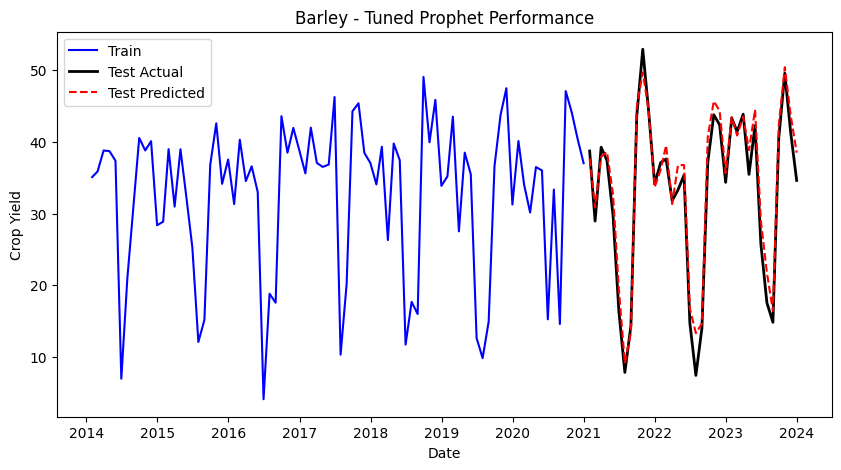

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


📈 Saved future forecast → final_forecasts/Barley_final_forecast.csv

🌾 Training MODEL for Sugarcane
🔍 Running hyperparameter search...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

✅ Best params → CPS: 0.5, SPS: 10.0, Mode: additive


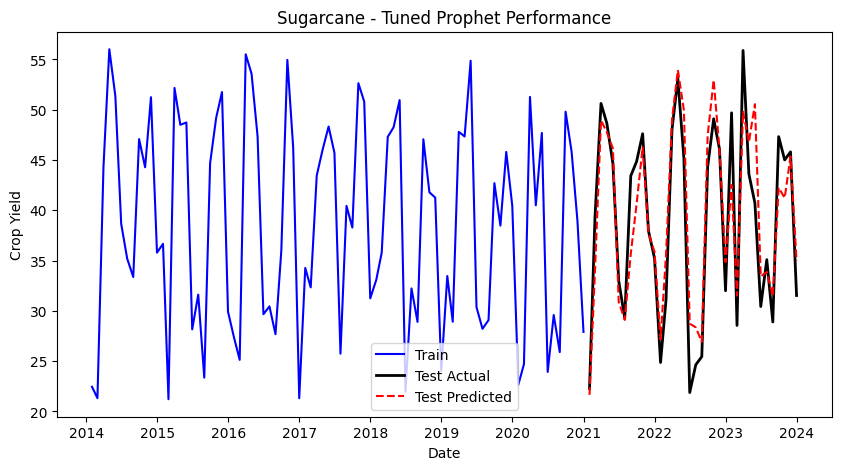

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


📈 Saved future forecast → final_forecasts/Sugarcane_final_forecast.csv

🌾 Training MODEL for Corn
🔍 Running hyperparameter search...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

✅ Best params → CPS: 0.5, SPS: 10.0, Mode: additive


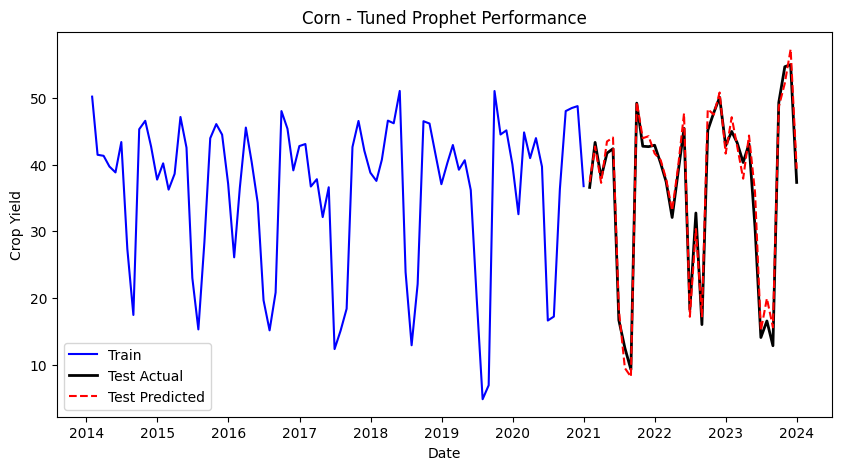

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


📈 Saved future forecast → final_forecasts/Corn_final_forecast.csv

🌾 Training MODEL for Cotton
🔍 Running hyperparameter search...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

✅ Best params → CPS: 0.5, SPS: 10.0, Mode: additive


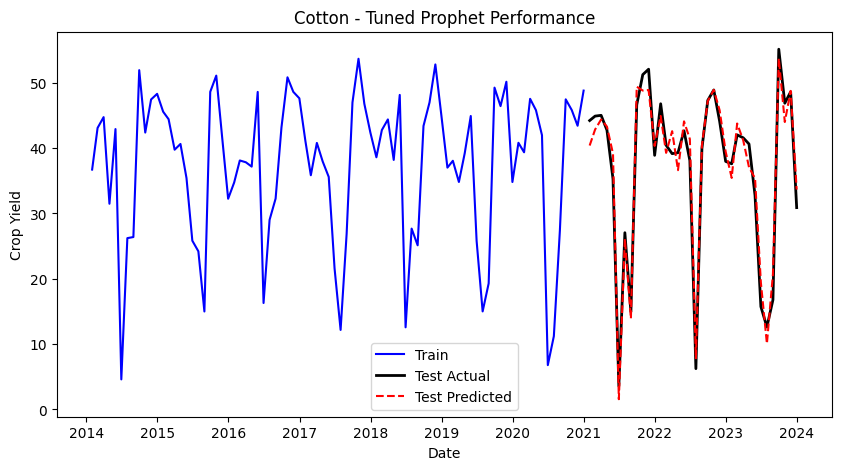

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


📈 Saved future forecast → final_forecasts/Cotton_final_forecast.csv

🌾 Training MODEL for Wheat
🔍 Running hyperparameter search...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

✅ Best params → CPS: 0.5, SPS: 10.0, Mode: additive


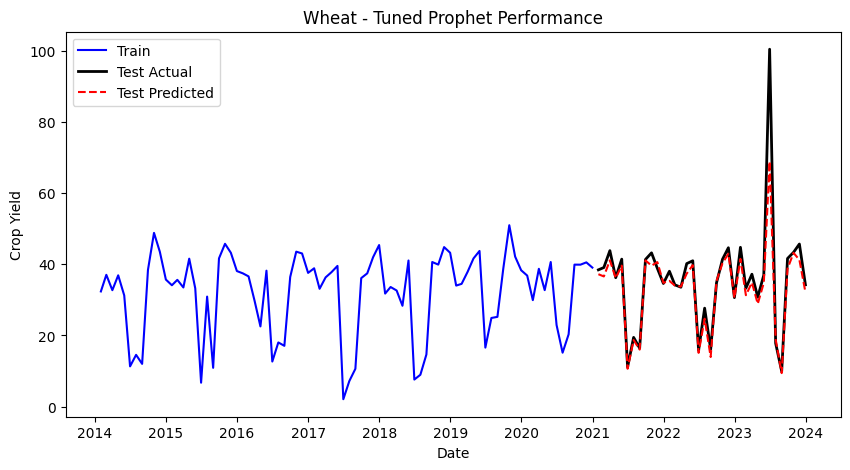

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


📈 Saved future forecast → final_forecasts/Wheat_final_forecast.csv

🌾 Training MODEL for Potato
🔍 Running hyperparameter search...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

✅ Best params → CPS: 0.5, SPS: 10.0, Mode: additive


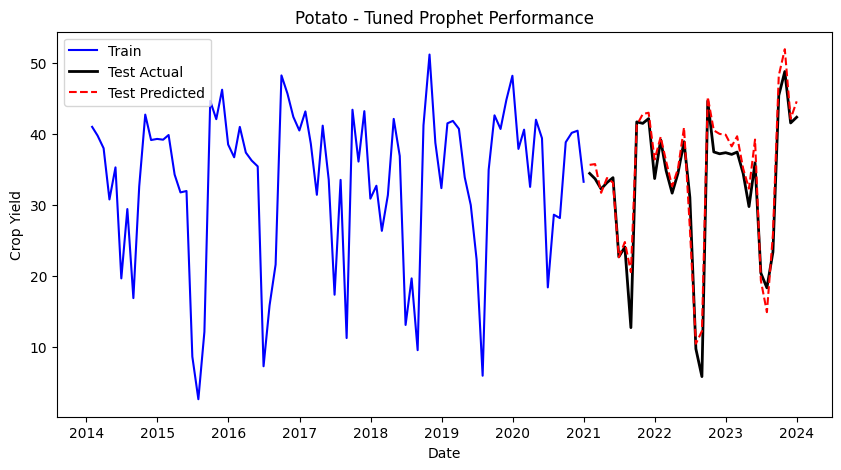

📈 Saved future forecast → final_forecasts/Potato_final_forecast.csv

✅ STEP 3 COMPLETED (WITH HYPERPARAMETER TUNING)

   Crop Name       MAE        MSE      RMSE  MAPE (%)     R²
6       Corn  1.578313   3.606690  1.899129      5.87  0.978
3  Sunflower  1.413397   3.213178  1.792534      4.31  0.976
2    Soybean  1.283767   2.930982  1.712011      4.45  0.972
7     Cotton  1.993696   5.325484  2.307701      8.22  0.968
4     Barley  1.908456   5.333757  2.309493      8.57  0.962
9     Potato  1.953103   6.543289  2.557985      9.60  0.932
1       Rice  2.897364  15.122471  3.888762      8.77  0.896
8      Wheat  2.400145  31.306797  5.595248      5.47  0.859
5  Sugarcane  3.069462  14.944889  3.865862      8.29  0.834
0     Tomato  2.685908  10.205885  3.194665      9.10  0.798


In [105]:
# ===========================================
# STEP 3: Train/Test Prophet with Regressors (AUTO HYPERPARAMETER TUNING)
# ===========================================

import pandas as pd
import glob
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import os
import itertools

monthly_folder = "monthly_series_by_crop_with_regressors"
future_reg_folder = "future_regressors"

files = glob.glob(monthly_folder + "/*.csv")

FORECAST_HORIZON = 36
N_MONTHS_FUTURE = 24

results = []
models = {} # Initialize dictionary to store trained models

# =========================================================
# PROPHET HYPERPARAMETER TUNING FUNCTION
# =========================================================
def tune_prophet(train_df, regressors):
    param_grid = {
        "changepoint_prior_scale": [0.05, 0.1, 0.5],
        "seasonality_prior_scale": [1.0, 5.0, 10.0],
        "seasonality_mode": ["additive", "multiplicative"]
    }

    all_params = list(itertools.product(
        param_grid["changepoint_prior_scale"],
        param_grid["seasonality_prior_scale"],
        param_grid["seasonality_mode"]
    ))

    best_mse = float("inf")
    best_params = None

    for cp, sp, sm in all_params:
        try:
            model = Prophet(
                changepoint_prior_scale=cp,
                seasonality_prior_scale=sp,
                seasonality_mode=sm,
                yearly_seasonality=True
            )

            for r in regressors:
                model.add_regressor(r)

            model.fit(train_df)

            pred_train = model.predict(train_df)
            mse = ((train_df["y"] - pred_train["yhat"]) ** 2).mean()

            if mse < best_mse:
                best_mse = mse
                best_params = (cp, sp, sm)

        except Exception as e:
            continue

    return best_params


# =========================================================
# MAIN LOOP THROUGH CROPS
# =========================================================
for file in files:

    base = os.path.basename(file)
    crop_name = base.replace("_monthly_with_regressors.csv", "")

    print("\n====================")
    print(f"🌾 Training MODEL for {crop_name}")
    print("====================")

    df = pd.read_csv(file)
    df["ds"] = pd.to_datetime(df["ds"])

    regressors = [c for c in df.columns if c not in ["ds", "y"]]

    if len(df) <= FORECAST_HORIZON + 12:
        print(f"⏭️ Not enough data for {crop_name}, skipping...")
        continue

    train = df.iloc[:-FORECAST_HORIZON].copy()
    test = df.iloc[-FORECAST_HORIZON:].copy()

    # =====================================================
    # 1) AUTO TUNE PROPHET HYPERPARAMETERS
    # =====================================================
    print("🔍 Running hyperparameter search...")
    best_params = tune_prophet(train, regressors)

    if best_params is None:
        print("❌ No valid param combination found, using default model.")
        best_params = (0.1, 5.0, "multiplicative")

    cp, sp, sm = best_params
    print(f"✅ Best params → CPS: {cp}, SPS: {sp}, Mode: {sm}")

    # =====================================================
    # 2) TRAIN FINAL MODEL WITH BEST PARAMS
    # =====================================================
    model = Prophet(
        yearly_seasonality=True,
        changepoint_prior_scale=cp,
        seasonality_prior_scale=sp,
        seasonality_mode=sm
    )

    for reg in regressors:
        model.add_regressor(reg)

    model.fit(train)
    models[crop_name] = model # Store the trained model

    # =====================================================
    # 3) TEST PREDICTION
    # =====================================================
    future_test = test[["ds"] + regressors].copy()
    forecast_test = model.predict(future_test)
    pred = forecast_test["yhat"].values

    mae = mean_absolute_error(test["y"], pred)
    mse = mean_squared_error(test["y"], pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((test["y"] - pred) / test["y"])) * 100
    r2 = r2_score(test["y"], pred)

    results.append([crop_name, mae, mse, rmse, round(mape, 2), round(r2, 3)])

    # =====================================================
    # 4) VISUALIZE
    # =====================================================
    plt.figure(figsize=(10, 5))
    plt.plot(train["ds"], train["y"], label="Train", color="blue")
    plt.plot(test["ds"], test["y"], label="Test Actual", color="black", linewidth=2)
    plt.plot(test["ds"], pred, "--", label="Test Predicted", color="red")
    plt.title(f"{crop_name} - Tuned Prophet Performance")
    plt.xlabel("Date")
    plt.ylabel("Crop Yield")
    plt.legend()
    plt.show()

    # =====================================================
    # 5) FUTURE FORECAST
    # =====================================================
    future_reg_file = os.path.join(future_reg_folder, f"{crop_name}_future_regressors.csv")

    if not os.path.exists(future_reg_file):
        print(f"⚠️ Missing future regressors for {crop_name}, skipping...")
        continue

    future_reg = pd.read_csv(future_reg_file)
    future_reg["ds"] = pd.to_datetime(future_reg["ds"])
    future_reg = future_reg.iloc[:N_MONTHS_FUTURE]

    forecast_future = model.predict(future_reg)

    os.makedirs("final_forecasts", exist_ok=True)
    out_path = f"final_forecasts/{crop_name}_final_forecast.csv"
    forecast_future.to_csv(out_path, index=False)

    print(f"📈 Saved future forecast → {out_path}")


# =====================================================
# FINAL SUMMARY
# =====================================================
performance_df = pd.DataFrame(results, columns=[
    "Crop Name", "MAE", "MSE", "RMSE", "MAPE (%)", "R²"
])

print("\n======================")
print("✅ STEP 3 COMPLETED (WITH HYPERPARAMETER TUNING)")
print("======================\n")
print(performance_df.sort_values("R²", ascending=False))

In [106]:
# ===========================================
# STEP 4: Combine All Forecasts Into One CSV
# ===========================================

import glob
import pandas as pd
import os

forecast_files = glob.glob("final_forecasts/*.csv")
combined = []

for file in forecast_files:
    crop_name = os.path.basename(file).replace("_final_forecast.csv", "")
    df = pd.read_csv(file)
    df["Crop_Name"] = crop_name
    combined.append(df)

final_dashboard = pd.concat(combined, ignore_index=True)
final_dashboard.to_csv("ALL_CROP_FORECASTS_DASHBOARD.csv", index=False)

print("✔ Saved: ALL_CROP_FORECASTS_DASHBOARD.csv")
final_dashboard.head()


✔ Saved: ALL_CROP_FORECASTS_DASHBOARD.csv


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Humidity,Humidity_lower,Humidity_upper,K,...,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,Crop_Name,extra_regressors_multiplicative,extra_regressors_multiplicative_lower,extra_regressors_multiplicative_upper
0,2024-01-31,30.609649,30.109127,32.446534,30.602688,30.617801,3.133878,3.133878,3.133878,-0.007943,...,-1.091560,-1.091560,0.0,0.0,0.0,31.215193,Wheat,NaN,NaN,NaN
1,2024-02-29,30.577973,29.911173,32.174086,30.542031,30.615840,3.185289,3.185289,3.185289,-0.008068,...,-1.308010,-1.308010,0.0,0.0,0.0,30.994210,Wheat,NaN,NaN,NaN
2,2024-03-31,30.544112,31.385715,33.815521,30.465936,30.628782,3.236700,3.236700,3.236700,-0.008194,...,0.348766,0.348766,0.0,0.0,0.0,32.644269,Wheat,NaN,NaN,NaN
3,2024-04-30,30.511344,30.427771,32.716955,30.387606,30.651196,3.288111,3.288111,3.288111,-0.008319,...,-0.687918,-0.687918,0.0,0.0,0.0,31.601960,Wheat,NaN,NaN,NaN
4,2024-05-31,30.477483,31.500793,33.946650,30.294600,30.682618,3.339522,3.339522,3.339522,-0.008445,...,0.443844,0.443844,0.0,0.0,0.0,32.727006,Wheat,NaN,NaN,NaN


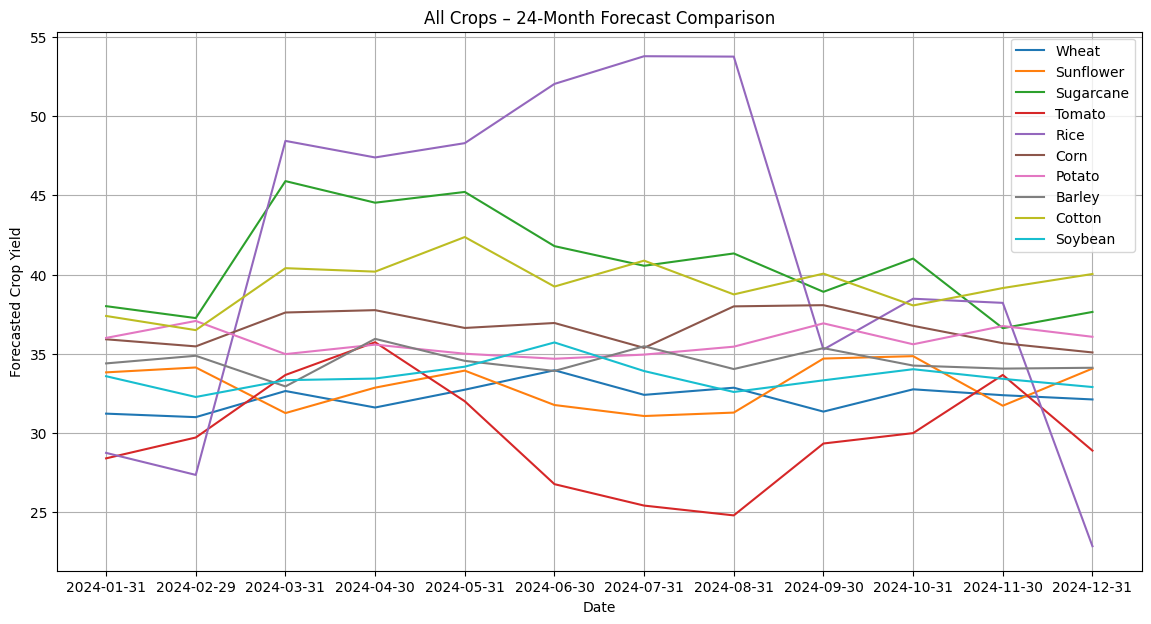

In [107]:
# ===========================================
# STEP 5: Plot all crop future forecasts together
# ===========================================

import matplotlib.pyplot as plt
import pandas as pd
import glob

plt.figure(figsize=(14, 7))

for file in glob.glob("final_forecasts/*.csv"):
    crop = os.path.basename(file).replace("_final_forecast.csv", "")
    df = pd.read_csv(file)
    plt.plot(df["ds"], df["yhat"], label=crop)

plt.title("All Crops – 24-Month Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Forecasted Crop Yield")
plt.legend()
plt.grid(True)
plt.show()


In [108]:
import os
import joblib

# === Path to save ===
save_path = "/content/drive/MyDrive/prophet-reg_models/"

# Create folder if not exists
os.makedirs(save_path, exist_ok=True)

# Loop through crop-wise Prophet models and save
for crop_name, model in models.items():
    file_name = f"{crop_name}_prophet_model.pkl"
    full_path = os.path.join(save_path, file_name)

    joblib.dump(model, full_path)

    print(f"✔ Saved: {full_path}")

print("\n=========================")
print("✅ All Prophet Models Saved Successfully!")
print("=========================")


✔ Saved: /content/drive/MyDrive/prophet-reg_models/Tomato_prophet_model.pkl
✔ Saved: /content/drive/MyDrive/prophet-reg_models/Rice_prophet_model.pkl
✔ Saved: /content/drive/MyDrive/prophet-reg_models/Soybean_prophet_model.pkl
✔ Saved: /content/drive/MyDrive/prophet-reg_models/Sunflower_prophet_model.pkl
✔ Saved: /content/drive/MyDrive/prophet-reg_models/Barley_prophet_model.pkl
✔ Saved: /content/drive/MyDrive/prophet-reg_models/Sugarcane_prophet_model.pkl
✔ Saved: /content/drive/MyDrive/prophet-reg_models/Corn_prophet_model.pkl
✔ Saved: /content/drive/MyDrive/prophet-reg_models/Cotton_prophet_model.pkl
✔ Saved: /content/drive/MyDrive/prophet-reg_models/Wheat_prophet_model.pkl
✔ Saved: /content/drive/MyDrive/prophet-reg_models/Potato_prophet_model.pkl

✅ All Prophet Models Saved Successfully!
